# Held-out images: baseline and the best variant of every stage (axis-100-3000)

How do the reconstruction error, the latent structure and the class probabilities of the best variant of each stage look on the held-out images compared with the baseline?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* Images are never averaged over repetitions. Each column is the representative repetition of one model cell
  (lowest mean rank of the key metrics on the test pixels); the best variant of a stage is chosen by the variant
  ranking on the test pixels, never on the displayed images.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_images"
AXIS = "axis-100-3000"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

pixel_maps = table('pixel_maps')
SHOWN = ['baseline', *STAGES]
shown = pixel_maps.drop_duplicates('shown_as').set_index('shown_as').reindex(SHOWN)
TITLES = [f"{STAGE_LABELS.get(stage, stage)}\n{VARIANT_LABELS[row.variant]}, rep {row.repetition}" if stage != 'baseline'
          else f"real-only baseline\nrep {row.repetition}" for stage, row in shown.iterrows()]
DATASETS = sorted(pixel_maps.dataset_id.unique())
display(shown[['variant', 'repetition', 'model_id']])

Analysis: stage_images | axis: axis-100-3000 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


,variant,repetition,model_id
shown_as,,,
baseline,baseline,1,metaspace-pretrain-repaired-20260923-01__grid_...
pretrained,P1_permutation,1,metaspace-pretrain-repaired-20260923-01__grid_...
frozen_head,P1_permutation,2,metaspace-pretrain-repaired-20260923-01__grid_...
unfrozen_head,P1_permutation,2,metaspace-pretrain-repaired-20260923-01__grid_...


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_images` selects the best variant of every stage (`select_best_variant`, test pixels), reads the
per-pixel held-out metrics, latent codes, head probabilities and reconstructed ion images of the displayed
representatives from the `inference` level, and the METASPACE intensities of the held-out images from the
`populations` level.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_images > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute channel-image agreement at every stage against the real-only baseline

### Methodology

#### Theoretical

The median Pearson correlation between input and reconstructed ion images of every held-out image, as a level
for the baseline and for the displayed models of every stage.

#### Implementation

`channel_improvements` holds the value of every model and the baseline value of the same repetition (`reference_value`).

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

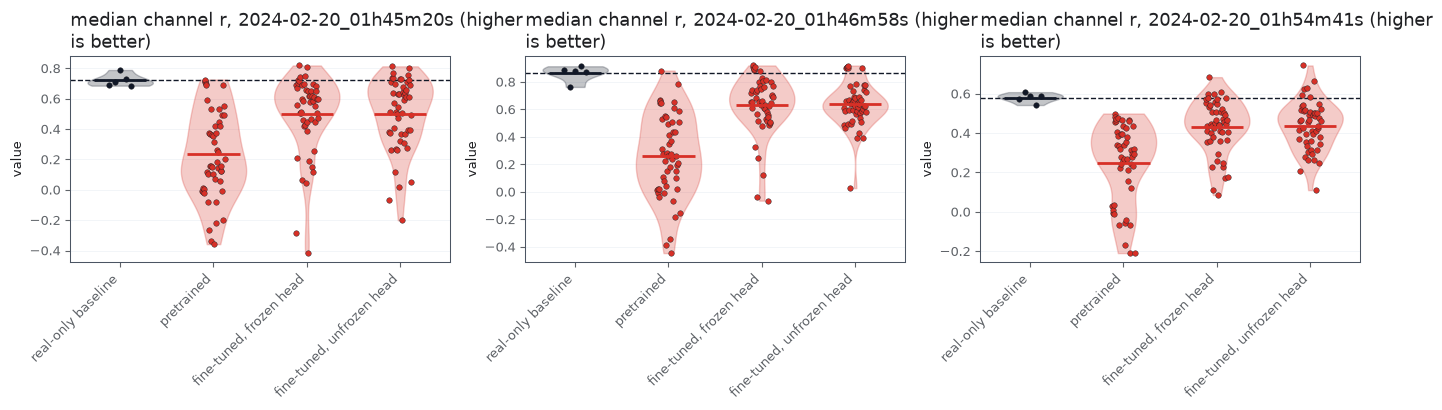

median channel r, 2024-02-20_01h45m20s


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.723 +/- 0.041,0.723 +/- 0.041,0.723 +/- 0.041
P0_single,-0.006 +/- 0.013,0.370 +/- 0.413,0.292 +/- 0.220
P1_permutation,0.708 +/- 0.016,0.741 +/- 0.045,0.754 +/- 0.039
P2_joint_base,0.094 +/- 0.319,0.455 +/- 0.232,0.486 +/- 0.234
P2_staged_base,0.219 +/- 0.340,0.553 +/- 0.112,0.403 +/- 0.126
P3_joint_overlap,0.224 +/- 0.122,0.539 +/- 0.311,0.511 +/- 0.282
P3_staged_overlap,0.045 +/- 0.334,0.253 +/- 0.409,0.344 +/- 0.344
P4_joint_rare,0.199 +/- 0.171,0.586 +/- 0.070,0.569 +/- 0.148
P4_staged_rare,0.321 +/- 0.207,0.433 +/- 0.276,0.510 +/- 0.176


median channel r, 2024-02-20_01h46m58s


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.863 +/- 0.058,0.863 +/- 0.058,0.863 +/- 0.058
P0_single,-0.000 +/- 0.026,0.676 +/- 0.052,0.561 +/- 0.084
P1_permutation,0.701 +/- 0.102,0.901 +/- 0.014,0.908 +/- 0.007
P2_joint_base,0.261 +/- 0.182,0.488 +/- 0.339,0.511 +/- 0.289
P2_staged_base,0.185 +/- 0.398,0.557 +/- 0.203,0.590 +/- 0.080
P3_joint_overlap,0.247 +/- 0.169,0.772 +/- 0.095,0.674 +/- 0.051
P3_staged_overlap,0.031 +/- 0.399,0.537 +/- 0.258,0.591 +/- 0.139
P4_joint_rare,0.367 +/- 0.111,0.667 +/- 0.116,0.604 +/- 0.100
P4_staged_rare,0.288 +/- 0.389,0.427 +/- 0.276,0.576 +/- 0.059


median channel r, 2024-02-20_01h54m41s


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.580 +/- 0.024,0.580 +/- 0.024,0.580 +/- 0.024
P0_single,0.012 +/- 0.020,0.465 +/- 0.094,0.393 +/- 0.117
P1_permutation,0.475 +/- 0.016,0.587 +/- 0.061,0.577 +/- 0.103
P2_joint_base,0.388 +/- 0.057,0.430 +/- 0.054,0.471 +/- 0.129
P2_staged_base,0.223 +/- 0.176,0.349 +/- 0.188,0.403 +/- 0.130
P3_joint_overlap,0.366 +/- 0.093,0.506 +/- 0.047,0.453 +/- 0.117
P3_staged_overlap,0.068 +/- 0.223,0.330 +/- 0.185,0.378 +/- 0.086
P4_joint_rare,0.328 +/- 0.087,0.464 +/- 0.097,0.464 +/- 0.148
P4_staged_rare,0.161 +/- 0.305,0.375 +/- 0.132,0.364 +/- 0.160


In [4]:
frame_abs = table('channel_improvements')
frame_abs = pd.concat([frame_abs.drop_duplicates(['repetition', *[c for c in ('dataset_id', 'evaluation', 'metric') if c in frame_abs]]).assign(variant=BASELINE, stage='real_only', value=lambda f: f.reference_value), frame_abs])
SELECTORS_ABS = [["median channel r, 2024-02-20_01h45m20s", {"evaluation": "2024-02-20_01h45m20s"}, "higher"], ["median channel r, 2024-02-20_01h46m58s", {"evaluation": "2024-02-20_01h46m58s"}, "higher"], ["median channel r, 2024-02-20_01h54m41s", {"evaluation": "2024-02-20_01h54m41s"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

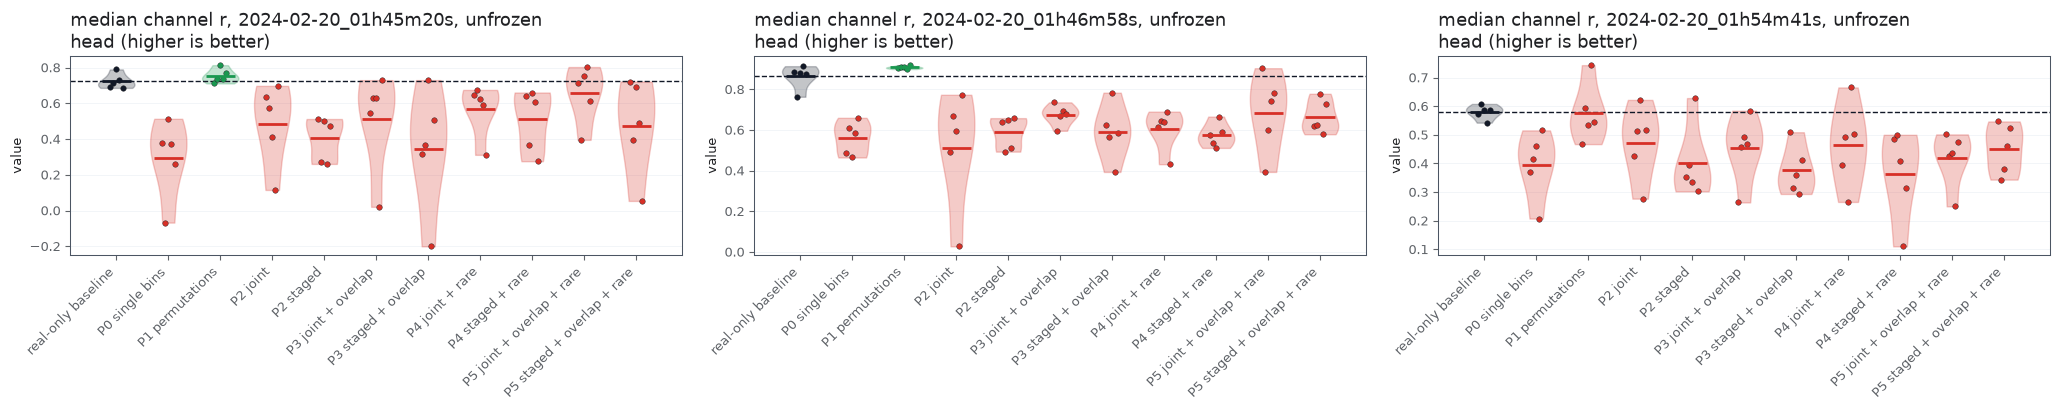

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- median channel r, 2024-02-20_01h45m20s (by stage, variants pooled): baseline 0.7226; others 0.2328-0.5005; 0 of 3 better than the baseline; best fine-tuned, frozen head (0.5005), worst pretrained (0.2328).
- median channel r, 2024-02-20_01h45m20s (unfrozen head, per variant): baseline 0.7226; others 0.2921-0.7538; 1 of 10 better than the baseline; best P1 permutations (0.7538), worst P0 single bins (0.2921).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.7538 vs baseline 0.7226).
- median channel r, 2024-02-20_01h46m58s (by stage, variants pooled): baseline 0.8631; others 0.2615-0.6364; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6364), worst pretrained (0.2615).
- median channel r, 2024-02-20_01h46m58s (unfrozen head, per variant): baseline 0.8631; others 0.5112-0.9079; 1 of 10 better than the baseline; best P1 permutations (0.9079), worst P2 joint (0.5112).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9079 vs baseline 0.8631).
- median channel r, 2024-02-20_01h54m41s (by stage, variants pooled): baseline 0.5795; others 0.2489-0.4371; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4371), worst pretrained (0.2489).
- median channel r, 2024-02-20_01h54m41s (unfrozen head, per variant): baseline 0.5795; others 0.3636-0.5767; 0 of 10 better than the baseline; best P1 permutations (0.5767), worst P4 staged + rare (0.3636).
  best single cell: P1 permutations, fine-tuned, frozen head (0.5874 vs baseline 0.5795).

### Notes

## Variant ranking per stage

### Methodology

#### Theoretical

The ranking that selects the displayed variant of each stage (part 2/3 overview notebooks).

#### Implementation

`selection` (variant ranking per stage).

#### Figure descriptions

No figure; rank of every variant per stage.

In [6]:
display(table('selection').pivot_table(index='variant', columns='stage', values='rank').reindex(VARIANTS)[STAGES])

stage,pretrained,frozen_head,unfrozen_head
variant,,,
P0_single,7.0,10.0,2.0
P1_permutation,1.0,1.0,1.0
P2_joint_base,4.0,5.0,7.0
P2_staged_base,9.0,6.0,10.0
P3_joint_overlap,3.0,3.0,5.0
P3_staged_overlap,8.0,7.0,8.0
P4_joint_rare,5.0,2.0,3.0
P4_staged_rare,10.0,8.0,9.0
P5_joint_all,2.0,4.0,4.0


### Remarks

- Displayed: baseline = baseline rep 1; pretrained = P1 permutations rep 1; frozen head = P1 permutations rep 2; unfrozen head = P1 permutations rep 2.

### Notes

## Reconstruction error maps

### Methodology

#### Theoretical

Per-pixel $W_1$ on the held-out images. Every panel has its own colour scale (colour bar), because the
pretrained model's error is an order of magnitude larger; compare spatial patterns across columns and
magnitudes via the colour bars and the table.

#### Implementation

`pixel_maps` (per shown model and held-out pixel).

#### Figure descriptions

Rows = held-out images, columns = baseline and the best variant of each stage; table: mean $W_1$ per image.

masserstein                                                 spectral_angle                                          
dataset_id    2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s 2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
shown_as                                                                                                                                   
baseline                     4.469                4.490                4.086                1.063                1.070                1.055
pretrained                 129.280              127.324              122.234                1.344                1.368                1.352
frozen_head                  3.925                3.875                3.924                0.935                0.930                0.931
unfrozen_head                3.586                3.659                3.427                0.940                0.941                0.932

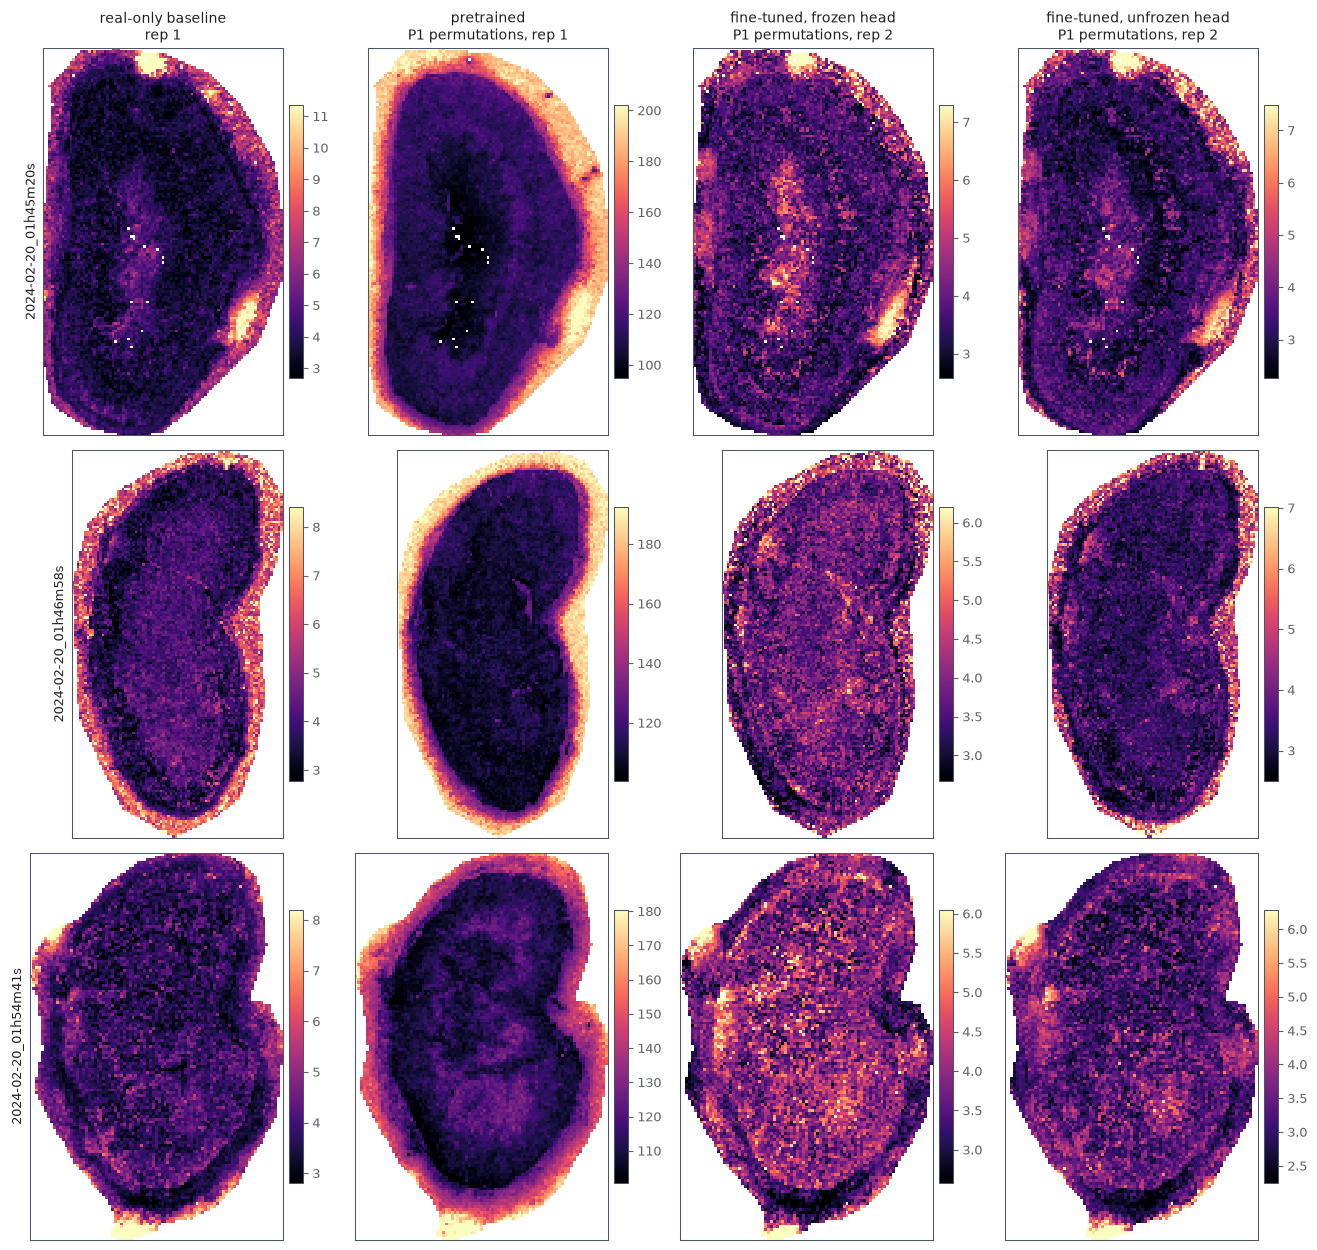

In [7]:
wide = pixel_maps.pivot_table(index=['row', 'dataset_id', 'x', 'y'], columns='shown_as', values='masserstein').reset_index()
figures.image_panels(wide, value_columns=SHOWN, column_titles=TITLES, datasets=DATASETS, shared_scale='panel', theme=theme);
display(pixel_maps.groupby(['shown_as', 'dataset_id'])[['masserstein', 'spectral_angle']].mean().unstack('dataset_id').reindex(SHOWN).round(3))

### Remarks

- Mean held-out W1 / spectral angle of the displayed models: baseline 4.36 / 1.06; pretrained 127 / 1.35; frozen head 3.91 / 0.932; unfrozen head 3.56 / 0.938. The fine-tuned error maps share the baseline's hot spots at the tissue edge; the pretrained map is dominated by the outer rim.

### Notes

## Spectral angle maps

### Methodology

#### Theoretical

Per-pixel spectral angle (shape error independent of the transport distance).

#### Implementation

`pixel_maps`.

#### Figure descriptions

As above, one colour scale per image row (the angle has comparable magnitudes across models).

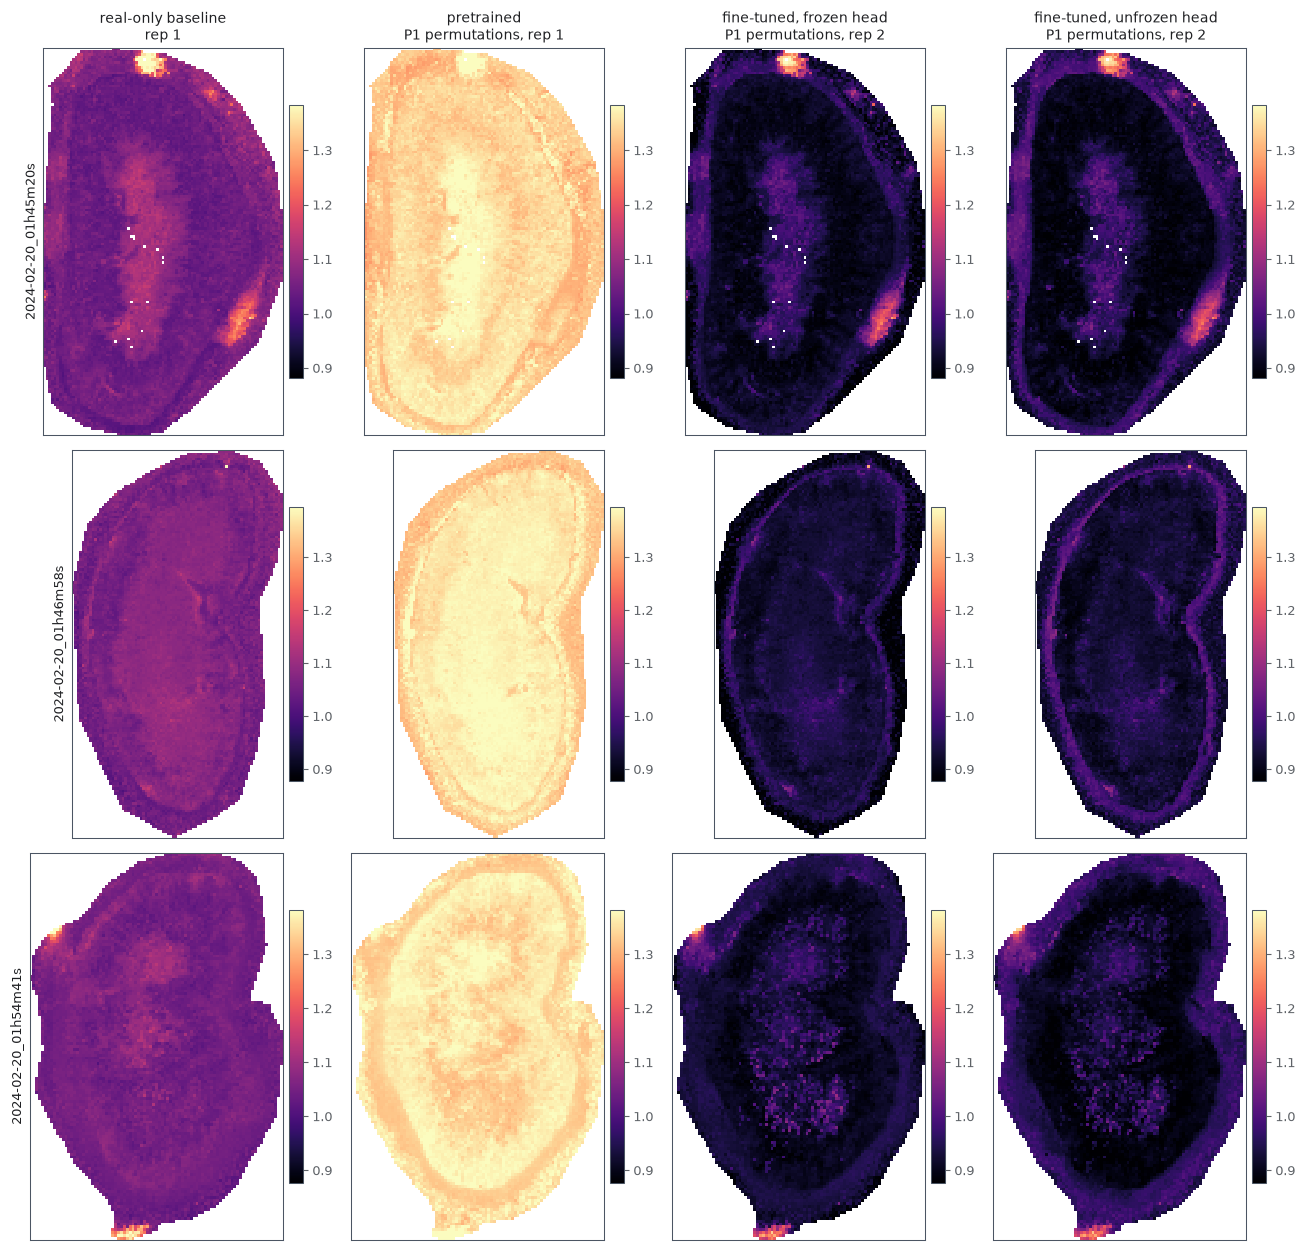

In [8]:
wide = pixel_maps.pivot_table(index=['row', 'dataset_id', 'x', 'y'], columns='shown_as', values='spectral_angle').reset_index()
figures.image_panels(wide, value_columns=SHOWN, column_titles=TITLES, datasets=DATASETS, shared_scale='row', theme=theme);

### Remarks

- The pretrained model's angle is uniformly high (about 1.35); the fine-tuned P1 models are below the baseline (0.93-0.94 against 1.06) over most of the tissue and share its hot spots at the tissue edge.

### Notes

## Latent structure as RGB

### Methodology

#### Theoretical

The first three principal components of each shown model's held-out codes, scaled to [0, 1] by their 1st
and 99th percentiles, as red, green and blue. Colours are not comparable between columns (each model has its
own components); spatial structure is.

#### Implementation

`latent_rgb` (seeded PCA per shown model).

#### Figure descriptions

Rows = held-out images, columns = shown models.

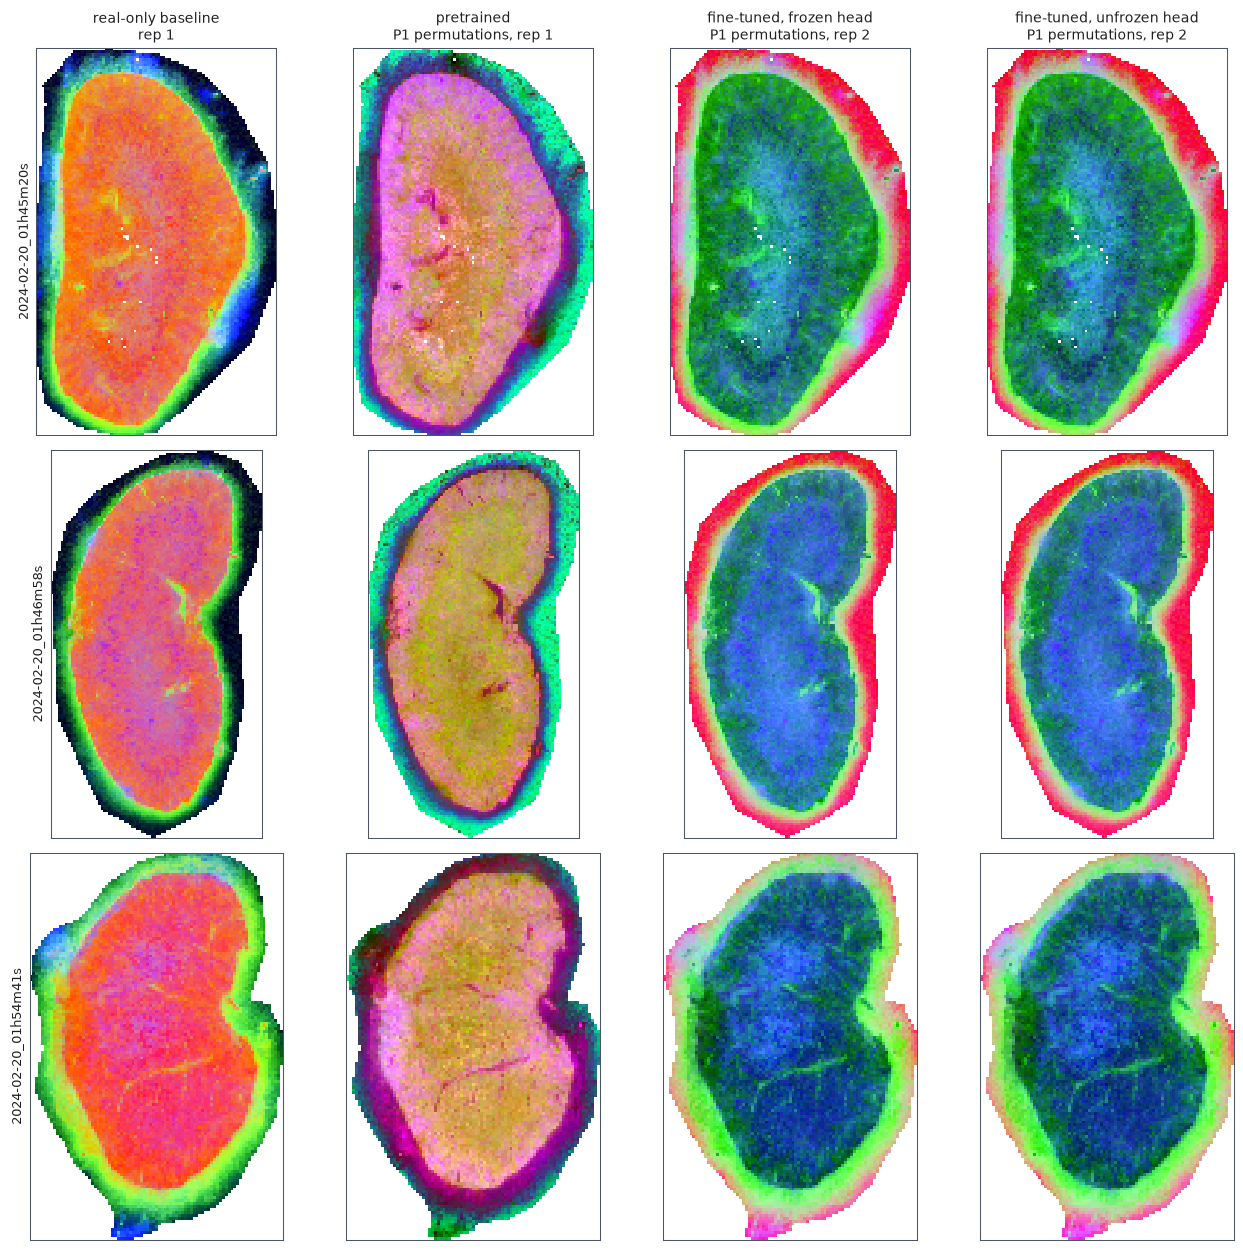

In [9]:
figures.rgb_panels(table('latent_rgb'), repetitions=SHOWN, datasets=DATASETS, column='shown_as', column_titles=TITLES, theme=theme);

### Remarks

- As on 200-900: the same rim / inner-tissue partition and fine structures in every model, including the pretrained one.

### Notes

## Class probability maps

### Methodology

#### Theoretical

For the three classes with the best and the three with the worst per-image AP of the baseline
representative (at least 20 annotated pixels in the image): METASPACE intensity, annotation (intensity >
0) and the probability of every shown model.

#### Implementation

`class_maps` (per class, pixel and shown model).

#### Figure descriptions

Rows = image | class | best/worst; columns = METASPACE intensity, annotation, then the probability of every
shown model. Every panel has its own colour scale (colour bar): the frozen synthetic head produces
probabilities of order 1e-5, which a shared [0, 1] range would render as a blank image.

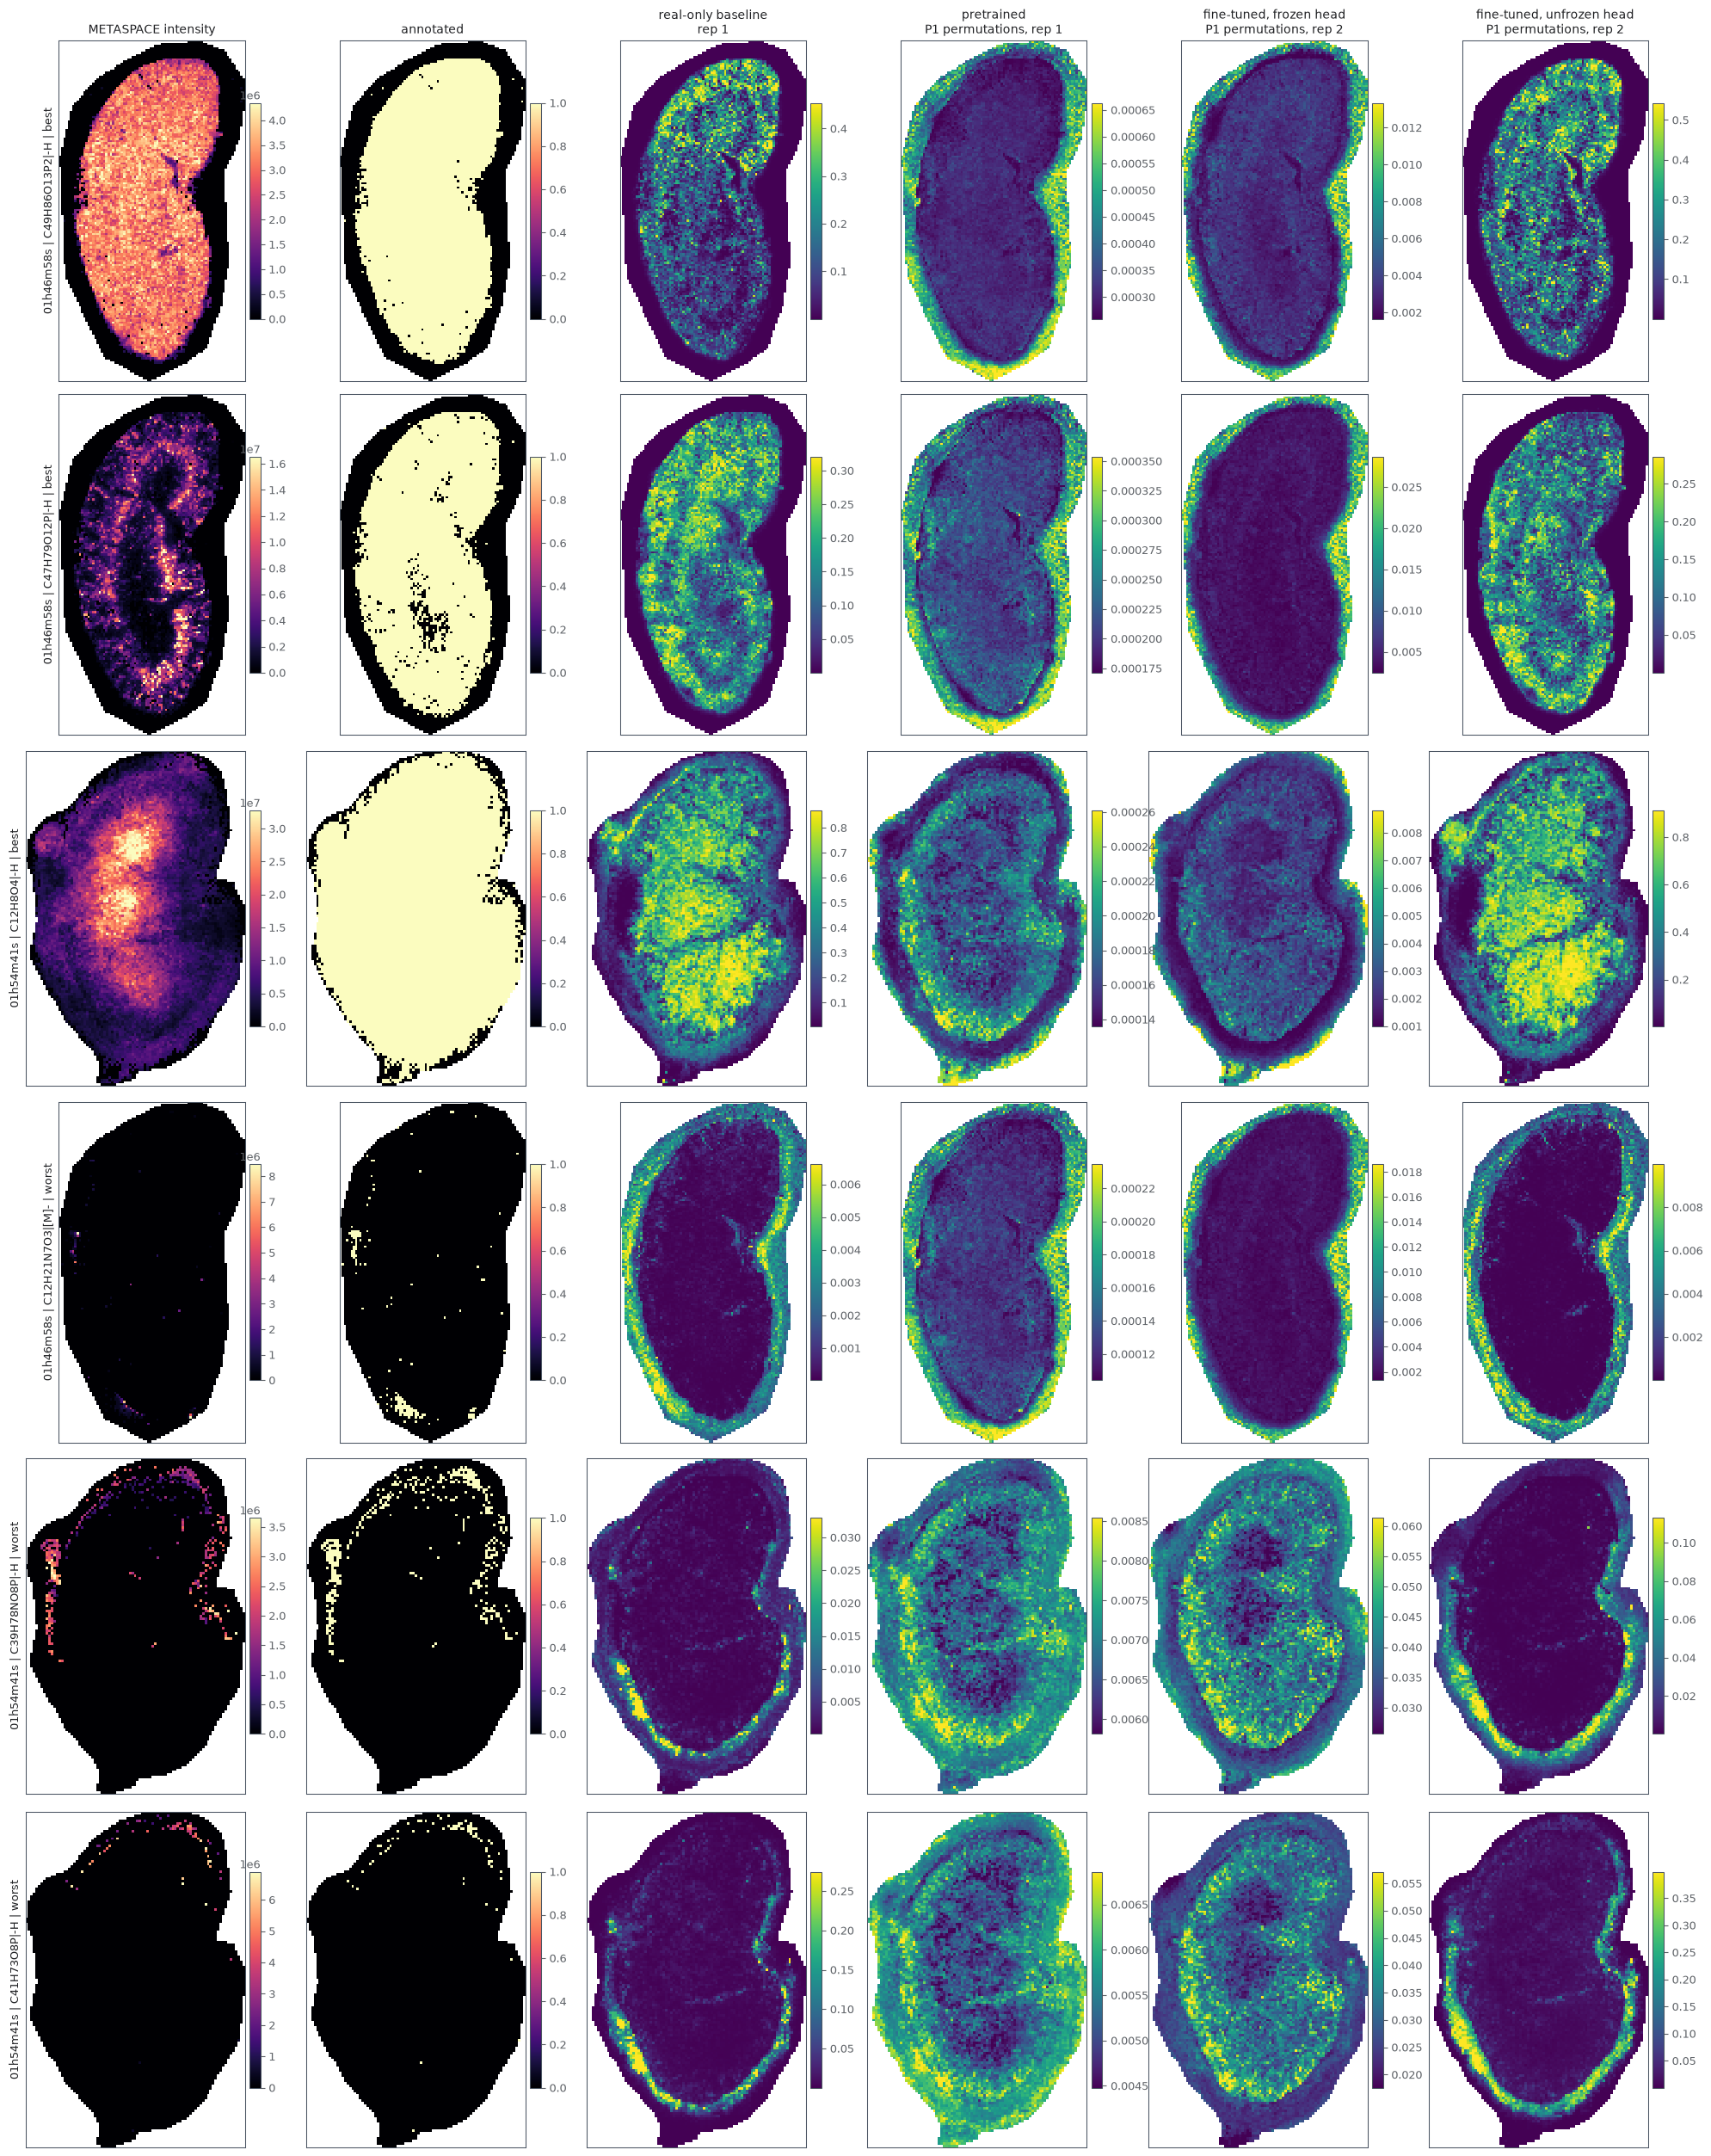

In [10]:
class_maps = table('class_maps')
class_maps['key'] = class_maps.dataset_id.str[-9:] + ' | ' + class_maps.class_name + ' | ' + class_maps.kind
## METASPACE intensity and annotation do not depend on the model; they are taken from the baseline rows
reference = class_maps[class_maps.shown_as == 'baseline'][['row', 'key', 'dataset_id', 'x', 'y', 'metaspace', 'annotated']]
wide = reference.merge(class_maps.pivot_table(index=['row', 'key'], columns='shown_as', values='probability').reset_index(), on=['row', 'key'])
KEYS = list(class_maps.sort_values(['kind', 'dataset_id']).key.unique())
figures.image_panels(wide, value_columns=['metaspace', 'annotated', *SHOWN], column_titles=['METASPACE intensity', 'annotated', *TITLES],
                     datasets=KEYS, row_column='key', shared_scale='panel', positive_columns=['metaspace'],
                     column_cmaps={name: theme.probability_colormap for name in SHOWN}, theme=theme);

### Remarks

- Same picture as on 200-900: the unfrozen P1 head matches the baseline's maps; the pretrained and frozen heads give tiny, spatially structured probabilities; the worst classes are over-predicted along the rim by every model.

### Notes

## Agreement of reconstructed ion images

### Methodology

#### Theoretical

For every held-out image and every annotated ion inside the axis, the Pearson correlation between the
input and the reconstructed ion image; the median over ions summarizes how well a model preserves the
spatial distribution of ions (part 1_05). Paired against the baseline for every model of the axis.

#### Implementation

`channel_improvements` (per model and image, paired), summarized here.

#### Figure descriptions

Forest plot: rows = variants, panels = stage x image.

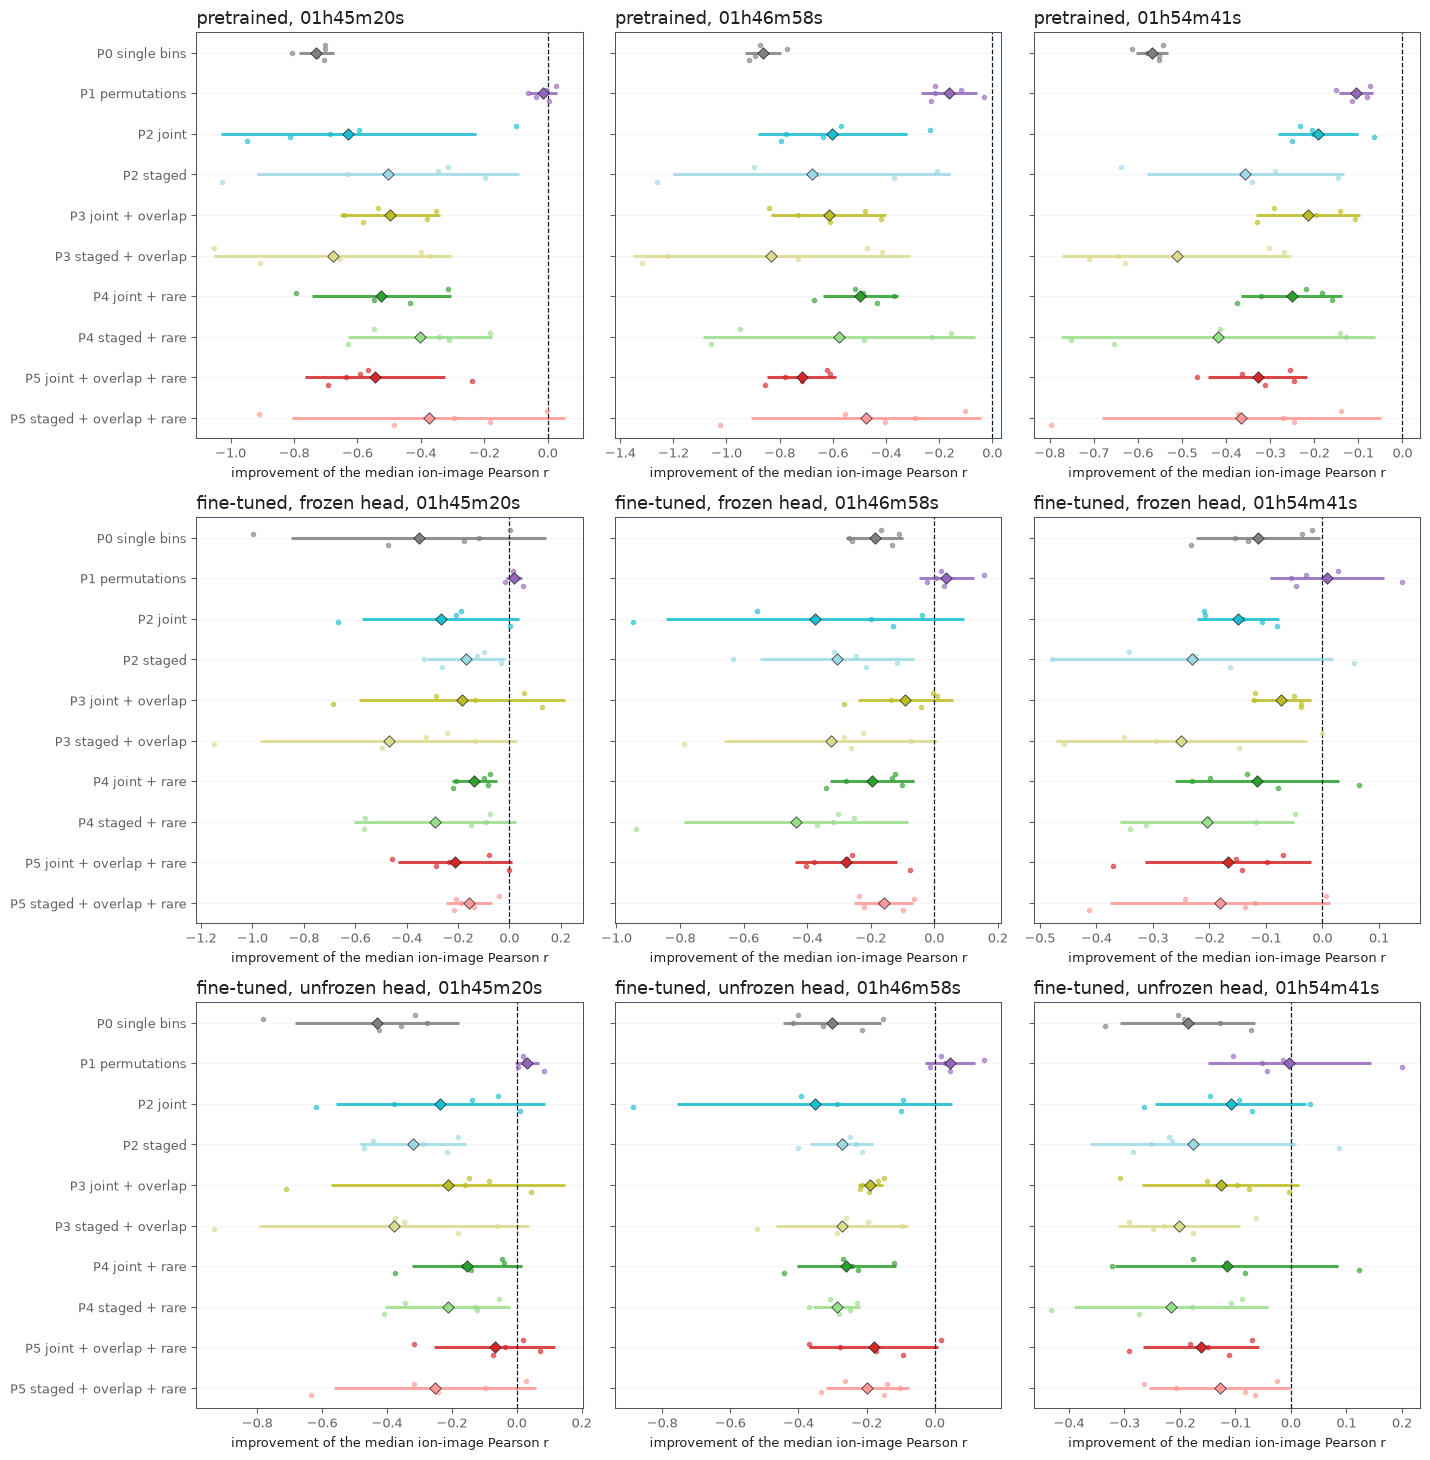

In [11]:
channels = table('channel_improvements')
channel_summary = summarize(channels, ['variant', 'stage', 'dataset_id'])
panels = [(f"{STAGE_LABELS[stage]}, {dataset[-9:]}", {'stage': stage, 'dataset_id': dataset}) for stage in STAGES for dataset in DATASETS]
figures.improvement_forest(channel_summary, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, paired=channels,
                           columns=3, xlabel='improvement of the median ion-image Pearson r', theme=theme);

### Remarks

- frozen head: median ion-image Pearson improvement -0.469 to 0.038; 0 improving and 15 worsening of 30 variant x image cells.
- pretrained: median ion-image Pearson improvement -0.863 to -0.0147; 0 improving and 28 worsening of 30 variant x image cells.
- unfrozen head: median ion-image Pearson improvement -0.43 to 0.0448; 0 improving and 15 worsening of 30 variant x image cells.

### Notes

## Results / Summary

### LLM

- **Observed:** on the wide axis P1 permutations is displayed at every stage; its fine-tuned representatives have lower held-out W1 (3.9 / 3.6) and spectral angle (0.93 / 0.94) than the baseline representative (4.4 / 1.06). This compares single representatives (different repetitions); the paired statistics are in 3_01 (held-out W1 improves significantly for P1).
- **Observed:** ion-image agreement is not improved by any variant (0 improving cells).
- **Interpretation:** P1 permutations is the only construction that improves the wide-axis reconstruction of new images without a significant shape penalty.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- median channel r, 2024-02-20_01h45m20s (by stage, variants pooled): baseline 0.7226; others 0.2328-0.5005; 0 of 3 better than the baseline; best fine-tuned, frozen head (0.5005), worst pretrained (0.2328).
- median channel r, 2024-02-20_01h45m20s (unfrozen head, per variant): baseline 0.7226; others 0.2921-0.7538; 1 of 10 better than the baseline; best P1 permutations (0.7538), worst P0 single bins (0.2921).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.7538 vs baseline 0.7226).
- median channel r, 2024-02-20_01h46m58s (by stage, variants pooled): baseline 0.8631; others 0.2615-0.6364; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6364), worst pretrained (0.2615).
- median channel r, 2024-02-20_01h46m58s (unfrozen head, per variant): baseline 0.8631; others 0.5112-0.9079; 1 of 10 better than the baseline; best P1 permutations (0.9079), worst P2 joint (0.5112).
  best single cell: P1 permutations, fine-tuned, unfrozen head (0.9079 vs baseline 0.8631).
- median channel r, 2024-02-20_01h54m41s (by stage, variants pooled): baseline 0.5795; others 0.2489-0.4371; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.4371), worst pretrained (0.2489).
- median channel r, 2024-02-20_01h54m41s (unfrozen head, per variant): baseline 0.5795; others 0.3636-0.5767; 0 of 10 better than the baseline; best P1 permutations (0.5767), worst P4 staged + rare (0.3636).
  best single cell: P1 permutations, fine-tuned, frozen head (0.5874 vs baseline 0.5795).

### Person